# Branch Prediction Homework (Wet Part)

## Goals
The goal of this homework is to understand how a 2-level branch predictor works
through implementation, experiments, and visual analysis. You will build a
configurable predictor that supports local or global history, local or
global pattern history tables (PHT), and ``gshare``/``lshare``-style XOR
indexing.

By the end of the lab you should be able to answer the following questions:
- When does local history help, and when does global history help?
- What is PHT aliasing and how does ``gshare`` deal with it?
- How do history length and total storage affect prediction accuracy?
- How does branch-prediction accuracy affect the CPI of the processor?

> **Note.** The dry questions for this homework live in a separate Hebrew
> PDF . This notebook contains the wet
> (coding) part only.


## Motivation: why we need branch prediction

In modern pipelined processors a conditional branch is only resolved late
in the pipeline (usually at execute, or even later). In the meantime the
processor must keep fetching instructions. If we wait until the branch
direction is known we waste several cycles on every branch. The standard
solution is **prediction**: guess the direction in advance, keep executing
along the predicted path, and only flush the pipeline if the guess turns
out to be wrong.

Branch-prediction accuracy therefore has a direct effect on processor
performance. For example, with branch frequency 20%, misprediction penalty
10 cycles, and a base CPI of 1:

$$ CPI_{\text{eff}} = CPI_{\text{base}} + \text{branch\_freq} \cdot \text{misprediction\_rate} \cdot \text{penalty} $$

so a predictor that mispredicts 10% of the time vs one that mispredicts 4%
of the time lowers the effective CPI from 1.20 to 1.08 , a ~10% improvement.

### Anatomy of a 2-level predictor
1. **History register.** Stores the last ``h`` outcomes. Can be global
   (GHR — one register shared by all branches) or local (BHR — one register
   per branch, kept in a Branch History Table).
2. **Pattern History Table (PHT).** A table of 2-bit saturating counters.
   Each entry encodes a prediction for a particular history pattern.
3. **Indexing.** The PHT is indexed by the history register, optionally
   XORed with the low bits of the branch address (gshare/lshare).

The API we will use throughout the lab is:
- ``BranchPredictor.predict(address)`` — return a prediction without
  changing state.
- ``BranchPredictor.update(address, taken)`` — update state with the actual
  outcome.
- ``BranchPredictor.predict_and_update(address, taken)`` — both in the
  required predict-then-update order.


In [1]:
import sys
from pathlib import Path

# Make the repository's ``src`` package importable regardless of where the
# notebook is launched from.
ROOT = Path.cwd()
if (ROOT / "src").exists():
    PROJECT_ROOT = ROOT
elif (ROOT.parent / "src").exists():
    PROJECT_ROOT = ROOT.parent
else:
    raise RuntimeError("Could not locate the project root.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt

from src import predictor
from src.lab_utils import (
    load_trace,
    run_trace,
    evaluate_predictor,
    compare_predictors,
    plot_prediction_timeline,
    plot_counter_evolution,
    plot_accuracy_vs_storage,
    plot_pht_accesses,
    simulate_single_counter,
    predictor_configs,
)

TRACES_DIR = PROJECT_ROOT / "traces"
print("Predictor module:", predictor.__name__)
print("Traces dir       :", TRACES_DIR)


Predictor module: src.predictor
Traces dir       : c:\Users\evyat\OneDrive\Desktop\College\MAMAS\hw2\traces


## Part 1: 2-bit saturating counter

Every dynamic branch predictor starts with a **2-bit saturating counter**.
The counter holds an internal value in $\{0, 1, 2, 3\}$ representing our
"confidence" that the branch is taken.

| Value | Name | Prediction |
|------:|:----:|:----------:|
| 0     | SNT (Strongly Not Taken) | N |
| 1     | WNT (Weakly Not Taken)   | N |
| 2     | WT  (Weakly Taken)       | T |
| 3     | ST  (Strongly Taken)     | T |

**Initial value:** WNT $= 1$.
**Update rule:** Taken $\Rightarrow$ saturating increment (max 3);
Not Taken $\Rightarrow$ saturating decrement (min 0).

**What to implement in ``src/predictor.py``:**
- ``counter_predict(counter)`` — returns ``True``/``False`` according to the
  encoding above.
- ``counter_update(counter, taken)`` — saturating update in $[0, 3]$.

Once these are implemented, running the next cell will produce a small
simulation and a plot of the counter's evolution.


**YOUR CODE:** finish ``counter_predict`` and ``counter_update`` in ``src/predictor.py``, then run the cell below.

counter states: [1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
predicted    : ['N', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T']
actual       : ['T', 'T', 'T', 'N', 'T', 'T', 'T', 'N', 'T', 'N', 'N', 'N', 'T', 'T', 'T', 'T', 'N']
accuracy     : 58.8%


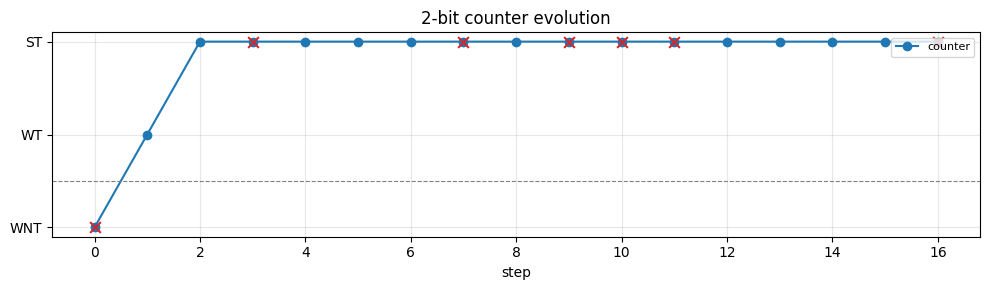

In [2]:
outcomes_text = "T T T N T T T N T N N N T T T T N"
outcomes = [c == "T" for c in outcomes_text.split()]

result = simulate_single_counter(outcomes, predictor)
print(f"counter states: {result['counter_states']}")
print(f"predicted    : {[ 'T' if p else 'N' for p in result['predicted']]}")
print(f"actual       : {[ 'T' if a else 'N' for a in result['actual']]}")
print(f"accuracy     : {result['accuracy'] * 100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 3))
plot_counter_evolution(result, ax=ax)
plt.tight_layout()
plt.show()


counter states: [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]
predicted    : ['N', 'T', 'N', 'T', 'N', 'T', 'N', 'T', 'N', 'T', 'N', 'T', 'N', 'T', 'N', 'T', 'N', 'T']
actual       : ['T', 'N', 'T', 'N', 'T', 'N', 'T', 'N', 'T', 'N', 'T', 'N', 'T', 'N', 'T', 'N', 'T', 'N']
accuracy     : 0.0%


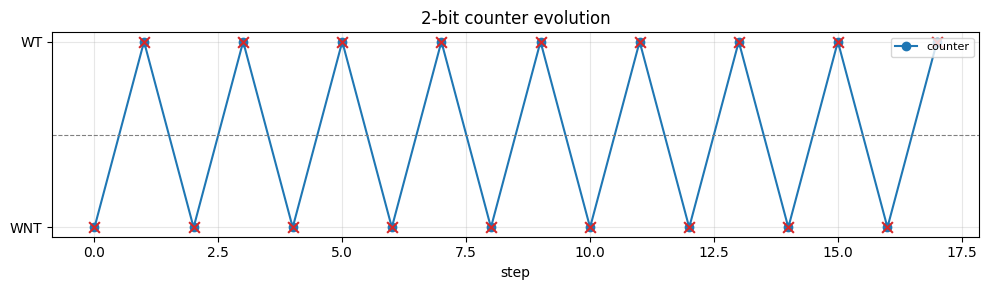

In [ ]:
# YOUR CODE:
# Try a different sequence and see how the counter evolves. For example
# T T N N T N N T T. Copy the previous cell and only change ``outcomes_text``.

outcomes_text = "T T T"
outcomes = [c == "T" for c in outcomes_text.split()]

result = simulate_single_counter(outcomes, predictor)
print(f"counter states: {result['counter_states']}")
print(f"predicted    : {[ 'T' if p else 'N' for p in result['predicted']]}")
print(f"actual       : {[ 'T' if a else 'N' for a in result['actual']]}")
print(f"accuracy     : {result['accuracy'] * 100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 3))
plot_counter_evolution(result, ax=ax)
plt.tight_layout()
plt.show()



Notice that a single saturating counter cannot learn complex patterns: it
only remembers the recent trend. To handle more complex patterns we add
**history**: a register that records recent outcomes and uses them to
select a different counter for every pattern.


## Part 2: simple global predictor (global history + global table)

The first complete predictor we build is the most basic one:
- **GHR** (Global History Register) of width ``history_size`` bits, holding
  the most recent branch outcomes (across all branches).
- A **global PHT** with $2^{history\_size}$ entries, each a 2-bit
  saturating counter.
- Indexing: ``index = GHR`` (no XOR with the address since ``share=False``).

**What to implement in ``predictor.py``:**
- ``update_history(history, taken, history_size)`` — shift and insert the
  new outcome.
- ``get_pht_index(address, history, history_size, share)`` — for
  ``share=False`` it is enough to return ``history`` itself.
- ``BranchPredictor.predict`` and ``BranchPredictor.update``.

Important: the prediction must be computed **before** the state is
updated. ``predict_and_update`` takes care of the right order
automatically, but inside your ``update`` make sure you compute the PHT
index from the current history (pre-update).


**YOUR CODE:** finish ``update_history``, ``get_pht_index`` (for ``share=False``), and ``BranchPredictor.predict`` / ``BranchPredictor.update``.

In [5]:
loop_cfg = predictor.PredictorConfig(
    history_size=4,
    history_table_size=1,        # not used for global history
    history_mode="global",
    table_mode="global",
    share=False,
)
res_loop = evaluate_predictor(loop_cfg, str(TRACES_DIR / "loop_pattern.trace"), predictor)
print(f"loop_pattern.trace  accuracy = {res_loop['accuracy'] * 100:.2f}%, "
      f"mispredictions = {res_loop['mispredictions']}, "
      f"storage = {res_loop['storage_bits']} bits")

fig, ax = plt.subplots(figsize=(10, 2.8))
plot_prediction_timeline(res_loop,
                         title="Timeline: global-global on loop_pattern",
                         ax=ax)
plt.tight_layout()
plt.show()


NotImplementedError: Implement BranchPredictor.predict

What is happening in the plot? The first iteration of the trace is full of
mispredictions because every PHT entry starts at WNT and has not been
trained yet. After two or three full iterations the GHR cycles through
five different values, one of which encodes "after four T's expect N" and
the rest encode "expect T". From that point onwards accuracy reaches 100%.


## Part 3: local history

So far the predictor used a single GHR shared by every branch. With **local
history** every branch is tracked separately: a **Branch History Table**
(BHT) is indexed by the branch address and returns that branch's private
BHR.

**Representation:**
- The BHT is **direct-mapped** with ``history_table_size`` entries.
- The index is the low bits of the address.
- The high bits of the address are the **tag**. If the stored tag does not
  match the new branch's tag we have a **tag miss**: the prediction
  defaults to Not Taken and the entry is reset for the new tag.

> **Note.** There is no single universal convention for what a predictor
> does after a tag miss — real designs differ. In this homework we *define*
> the default prediction after a tag miss to be **Not Taken**, and both the
> tests and the dry part follow this convention.

**What to implement in ``predictor.py``:**
- ``get_local_index(address, history_table_size)`` — BHT index.
- ``get_local_tag(address, history_table_size)`` — corresponding tag.

The logic that detects a tag miss and resets the entry is already
implemented inside ``BranchPredictor._lookup``, so once your helpers are
correct the rest of the code will just work.

### Example: two different branches mapping to the same BHT entry
We use ``history_table_size = 4``, so the index is the low 2 bits. The
addresses ``0x100`` and ``0x140`` have the same low 2 bits (``0``) but
different tags (``0x40`` vs ``0x50``). Below we first train ``0x100`` to be
always Taken, and then probe ``0x140`` — the very first prediction for it
must be N because of the tag miss.


**YOUR CODE:** finish ``get_local_index`` and ``get_local_tag``.

In [ ]:
demo_cfg = predictor.PredictorConfig(
    history_size=2,
    history_table_size=4,
    history_mode="local",
    table_mode="global",
    share=False,
)
bp = predictor.BranchPredictor(demo_cfg)
for _ in range(8):
    bp.predict_and_update(0x100, True)
print(f"after warm-up: predict(0x100) = {bp.predict(0x100)}  (expected True)")
print(f"first pred for 0x140        = {bp.predict(0x140)}  (expected False, tag miss)")

# Now run the alternating trace with a local predictor — it should easily
# converge to perfect predictions after a brief warm-up.
alt_cfg = predictor.PredictorConfig(
    history_size=2,
    history_table_size=16,
    history_mode="local",
    table_mode="global",
    share=False,
)
res_alt = evaluate_predictor(alt_cfg, str(TRACES_DIR / "alternating.trace"), predictor)
print(f"local on alternating.trace : accuracy = {res_alt['accuracy'] * 100:.2f}%, "
      f"mispredictions = {res_alt['mispredictions']}")

fig, ax = plt.subplots(figsize=(10, 2.8))
plot_prediction_timeline(res_alt,
                         title="Timeline: local-global on alternating",
                         ax=ax)
plt.tight_layout()
plt.show()


A short warm-up is needed before the local predictor stabilizes, but it
quickly learns the alternating pattern for that particular branch. Imagine
two branches with different private patterns, under a local predictor they
do not interfere with each other, while a global predictor sees both
patterns interleaved in a single GHR and may mix them up. The
``private_patterns.trace`` used in Part 6 demonstrates exactly this
scenario: a 5-iteration loop branch interleaved with an alternating branch.


## Part 4: local tables vs a global table

Up to now we assumed a single global PHT. The alternative is to keep a
**private** PHT inside each entry of the local history table, every
branch then gets its own set of $2^{history\_size}$ counters. This
reduces interference between branches but costs significantly more bits.

| Configuration  | Storage (bits) |
|----------------|----------------|
| global-global  | $history\_size + 2 \cdot 2^{history\_size}$ |
| local-global   | $hts \cdot (1 + tag\_bits + hsize) + 2 \cdot 2^{hsize}$ |
| local-local    | $hts \cdot (1 + tag\_bits + hsize + 2 \cdot 2^{hsize})$ |

where $hts = $ ``history_table_size``, $hsize = $ ``history_size``, and
$tag\_bits = address\_bits - \log_2 hts$.


In [ ]:
configs = predictor_configs(predictor, history_size=4, history_table_size=16)
print("Storage cost (bits) of each predictor:")
for name, cfg in configs.items():
    bp = predictor.BranchPredictor(cfg)
    print(f"  {name:<14s}: {bp.storage_bits():>5d} bits")

# Accuracy comparison on a few traces:
sel_traces = [
    str(TRACES_DIR / "alternating.trace"),
    str(TRACES_DIR / "correlated_branches.trace"),
    str(TRACES_DIR / "mixed_workload.trace"),
]
summary = compare_predictors(configs, sel_traces, predictor)


Note the dramatic gap in storage between ``global-global`` and
``local-local``: for the same history length and table size,
``local-local`` is about 30x larger. The economic question is whether the
accuracy improvement is worth that overhead.


## Part 5: lshare and gshare

The classical problem with a plain global-global predictor is **aliasing**:
when different branches reach the same GHR value they index the same PHT
entry and "interfere" with each other. The ``gshare`` idea is to mix the
branch address into the index using XOR:

$$ \text{index} = \text{GHR} \oplus (\text{PC} \bmod 2^{\text{history\_size}}) $$

- With **global** history this is the classical ``gshare`` configuration.
- With **local** history and a global PHT this is called ``lshare``.

**What to implement in ``predictor.py``:**
- The ``share=True`` branch of ``get_pht_index``.

Below we compare ``global-global`` against ``gshare`` on two scenarios. In
both, an always-Taken branch and an always-Not-Taken branch execute in
blocks of 5, so at every block boundary both branches see the *same* GHR
value and fight over the same PHT counters which is destructive aliasing.
- ``aliasing_bad.trace``: the addresses (``0x100``, ``0x200``) share their
  low bits, so the XOR cannot separate them.
- ``aliasing_good.trace``: the addresses (``0x103``, ``0x205``) differ in
  their low bits, so the XOR can disambiguate.


**YOUR CODE:** extend ``get_pht_index`` so that ``share=True`` produces the XOR-based gshare/lshare index.

In [ ]:
aliasing_cfg_pairs = {
    "global-global": predictor.PredictorConfig(history_size=4, history_table_size=16,
                                               history_mode="global", table_mode="global",
                                               share=False),
    "gshare":        predictor.PredictorConfig(history_size=4, history_table_size=16,
                                               history_mode="global", table_mode="global",
                                               share=True),
    "local-global":  predictor.PredictorConfig(history_size=4, history_table_size=16,
                                               history_mode="local", table_mode="global",
                                               share=False),
    "lshare":        predictor.PredictorConfig(history_size=4, history_table_size=16,
                                               history_mode="local", table_mode="global",
                                               share=True),
}

aliasing_traces = [
    str(TRACES_DIR / "aliasing_bad.trace"),
    str(TRACES_DIR / "aliasing_good.trace"),
]
compare_predictors(aliasing_cfg_pairs, aliasing_traces, predictor)

# Visualize PHT-access concentration for the bad-aliasing case.
res_bad_global = evaluate_predictor(aliasing_cfg_pairs["global-global"],
                                    str(TRACES_DIR / "aliasing_bad.trace"),
                                    predictor)
res_bad_gshare = evaluate_predictor(aliasing_cfg_pairs["gshare"],
                                    str(TRACES_DIR / "aliasing_bad.trace"),
                                    predictor)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
plot_pht_accesses(res_bad_global, title="aliasing_bad: global-global", ax=axes[0])
plot_pht_accesses(res_bad_gshare, title="aliasing_bad: gshare",        ax=axes[1])
plt.tight_layout()
plt.show()


On both traces ``global-global`` suffers: around every block boundary the
two opposite-bias branches index the same PHT counters (the GHR is all-1s
after 0x100's block and all-0s after 0x200's block) and keep retraining
them in opposite directions. On ``aliasing_bad.trace`` the low bits of the
two branch addresses are the same (``0x100`` and ``0x200``), so XOR does
not change the PHT index and ``gshare`` behaves *identically* to
``global-global``. On ``aliasing_good.trace`` the low bits differ and
``gshare`` succeeds in mapping the two branches to different PHT entries,
eliminating the destructive interference. The PHT-access plots make the
difference visible: with gshare on ``aliasing_good`` the accesses spread
over disjoint sets of indices.


## Part 6: experiments and predictor comparison

Now we compare all five configurations
(``global-global``, ``gshare``, ``local-global``, ``lshare``,
``local-local``) on every trace we have. We look at accuracy, the number of
mispredictions, the storage cost, and a visual comparison of accuracy vs
storage.


In [ ]:
configs = predictor_configs(predictor, history_size=4, history_table_size=16)
all_traces = [
    str(TRACES_DIR / "always_taken.trace"),
    str(TRACES_DIR / "loop_pattern.trace"),
    str(TRACES_DIR / "alternating.trace"),
    str(TRACES_DIR / "private_patterns.trace"),
    str(TRACES_DIR / "correlated_branches.trace"),
    str(TRACES_DIR / "aliasing_bad.trace"),
    str(TRACES_DIR / "aliasing_good.trace"),
    str(TRACES_DIR / "mixed_workload.trace"),
]
summary = compare_predictors(configs, all_traces, predictor)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_accuracy_vs_storage(summary,
                         title="Average accuracy vs storage cost",
                         ax=ax)
plt.tight_layout()
plt.show()

# Mispredictions per trace, side by side per predictor.
trace_names = list(summary.keys())
config_names = list(configs.keys())
fig, ax = plt.subplots(figsize=(11, 4))
bar_width = 0.16
xs = list(range(len(trace_names)))
for i, name in enumerate(config_names):
    ys = [summary[t][name]["mispredictions"] for t in trace_names]
    ax.bar([x + i * bar_width for x in xs], ys, width=bar_width, label=name)
ax.set_xticks([x + bar_width * 2 for x in xs])
ax.set_xticklabels([t.replace(".trace", "") for t in trace_names], rotation=20, ha="right")
ax.set_ylabel("mispredictions")
ax.set_title("Mispredictions per predictor and trace")
ax.grid(True, alpha=0.3, axis="y")
ax.legend(loc="upper left", fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

# Prediction timeline for the mixed workload — gshare row.
res_mix_gshare = evaluate_predictor(configs["gshare"],
                                    str(TRACES_DIR / "mixed_workload.trace"),
                                    predictor)
fig, ax = plt.subplots(figsize=(11, 2.6))
plot_prediction_timeline(res_mix_gshare,
                         title="gshare on mixed_workload",
                         ax=ax)
plt.tight_layout()
plt.show()
